Dataset exploration exercise 1

1. Libary and device setup

In [19]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report

In [20]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [21]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),  
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root=r"C:\SUTD\50.039 Deep Learning\PROJECT\face_images_scraped_from_unsplash_high_quality_with_noise\beardedface-images",
    transform=transform
)

print("Train classes:", train_dataset.classes)
print("Train mapping:", train_dataset.class_to_idx)

selected_indices = list(range(min(5000, len(train_dataset))))
train_subset = Subset(train_dataset, selected_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

print("Subset training size:", len(train_subset))
print("Number of training batches:", len(train_loader))

Train classes: ['images']
Train mapping: {'images': 0}
Subset training size: 5000
Number of training batches: 157


In [22]:
images, labels = next(iter(train_loader))
print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Unique labels:", labels.unique())

Image shape: torch.Size([32, 3, 32, 32])
Label shape: torch.Size([32])
Unique labels: tensor([0])


In [23]:
# from collections import Counter

# train_labels = [label for _, label in train_dataset.samples]
# valid_labels = [label for _, label in valid_dataset.samples]

# train_counts = Counter(train_labels)
# valid_counts = Counter(valid_labels)

# print("Training set class counts:")
# for class_name, class_idx in train_dataset.class_to_idx.items():
#     print(f"{class_name}: {train_counts[class_idx]}")

# print("\nValidation set class counts:")
# for class_name, class_idx in valid_dataset.class_to_idx.items():
#     print(f"{class_name}: {valid_counts[class_idx]}")

2. Converts images to tensors, loads training and validation images from folder names as class labels, and creates batches for model training and validation.

In [24]:
# transform = transforms.Compose([
#     transforms.ToTensor()
# ])

# # Use subfolders as labels
# train_dataset = datasets.ImageFolder(
#     root="/Users/htetaunglwin/Desktop/Deepfake_detection/dataset/train",
#     transform=transform
# )

# # Use subfolders as labels
# valid_dataset = datasets.ImageFolder(
#     root="/Users/htetaunglwin/Desktop/Deepfake_detection/dataset/valid",
#     transform=transform
# )

# print("Train classes:", train_dataset.classes)
# print("Train mapping:", train_dataset.class_to_idx)

# print("Valid classes:", valid_dataset.classes)
# print("Valid mapping:", valid_dataset.class_to_idx)

# # Get indices for fake and real images in training set
# fake_indices = [i for i, (_, label) in enumerate(train_dataset.samples) if label == train_dataset.class_to_idx['fake']]
# real_indices = [i for i, (_, label) in enumerate(train_dataset.samples) if label == train_dataset.class_to_idx['real']]

# # Randomly select 10000 fake and 10000 real images
# selected_fake = random.sample(fake_indices, 10000)
# selected_real = random.sample(real_indices, 10000)

# # Combine and shuffle selected indices
# selected_indices = selected_fake + selected_real
# random.shuffle(selected_indices)

# # Create balanced training subset
# train_subset = Subset(train_dataset, selected_indices)

# # DataLoaders
# train_loader = DataLoader(train_subset, batch_size=32, shuffle=True) #mini-batch
# valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

# print("Subset training size:", len(train_subset))
# print("Number of training batches:", len(train_loader))

In [25]:
# # Get one batch of training images and labels
# images, labels = next(iter(train_loader))

# # Print batch shape
# print("Image batch shape:", images.shape)
# print("Label batch shape:", labels.shape)
# print("First 10 labels:", labels[:10])

In [26]:
# class SimpleCNN(nn.Module):
#     def __init__(self):
#         super(SimpleCNN, self).__init__()
        
#         self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
#         self.relu = nn.ReLU()
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
#         self.fc = nn.Linear(32 * 128 * 128, 2)  # for 256 x 256 input

#     def forward(self, x):
#         x = self.conv1(x)   # convolution
#         x = self.relu(x)    # activation
#         x = self.pool(x)    # pooling
#         x = x.view(x.size(0), -1)  # flatten
#         x = self.fc(x)      # final classification
#         return x

In [27]:
# # Create the model
# model = SimpleCNN().to(device)

# # Loss function
# criterion = nn.CrossEntropyLoss()

# # Optimizer
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# print(model)

In [28]:
# num_epochs = 5

# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0

#     for images, labels in train_loader:
#         images = images.to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#     model.eval()
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for images, labels in valid_loader:
#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model(images)
#             _, predicted = torch.max(outputs, 1)

#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()

#     val_accuracy = 100 * correct / total
#     avg_loss = running_loss / len(train_loader)

#     print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

In [29]:
class PretrainedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])

        for name, param in self.encoder.named_parameters():
            if "layer4" in name:   # only last ResNet block trains
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 512, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)          
        out = self.decoder(z)        
        return out

In [30]:
# train_dataset = Subset(train_dataset, selected_real)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [31]:
# num_epochs = 5
# model = PretrainedAutoencoder().to(device)
# optimizer = optim.Adam(model.parameters())


# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0

#     for images, _ in train_loader:
#         images = images.to(device)

#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = F.mse_loss(outputs, images)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#     model.eval()
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for images, labels in valid_loader:
#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model(images)
#             recon_loss = F.mse_loss(outputs, images, reduction=None)
#             recon_loss = recon_loss.mean(dim=[1,2,3])
#             _, predicted = torch.max(outputs, 1)

#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
    
#     val_accuracy = 100 * correct / total
#     avg_loss = running_loss / len(train_loader)

#     print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

In [32]:
num_epochs = 20
model = PretrainedAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = F.mse_loss(outputs, images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Reconstruction Loss: {avg_loss:.6f}")

c:\Users\thoai\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\thoai\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20], Reconstruction Loss: 0.062079
Epoch [2/20], Reconstruction Loss: 0.053069
Epoch [3/20], Reconstruction Loss: 0.050574
Epoch [4/20], Reconstruction Loss: 0.049274
Epoch [5/20], Reconstruction Loss: 0.048379
Epoch [6/20], Reconstruction Loss: 0.047690
Epoch [7/20], Reconstruction Loss: 0.046468
Epoch [8/20], Reconstruction Loss: 0.045700
Epoch [9/20], Reconstruction Loss: 0.045100
Epoch [10/20], Reconstruction Loss: 0.044392
Epoch [11/20], Reconstruction Loss: 0.044256
Epoch [12/20], Reconstruction Loss: 0.043576
Epoch [13/20], Reconstruction Loss: 0.043203
Epoch [14/20], Reconstruction Loss: 0.042931
Epoch [15/20], Reconstruction Loss: 0.042734
Epoch [16/20], Reconstruction Loss: 0.041893
Epoch [17/20], Reconstruction Loss: 0.041789
Epoch [18/20], Reconstruction Loss: 0.041267
Epoch [19/20], Reconstruction Loss: 0.041136
Epoch [20/20], Reconstruction Loss: 0.041450


In [35]:
model.eval()

with torch.no_grad():
    images, _ = next(iter(train_loader))
    images = images.to(device)
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 3, 32, 32])
Output shape: torch.Size([32, 3, 32, 32])


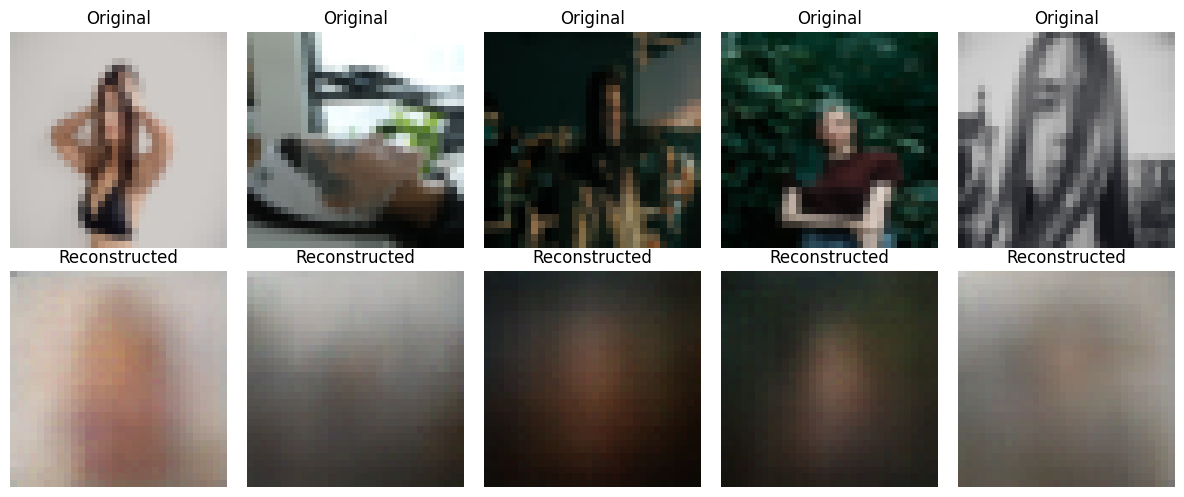

In [36]:
model.eval()

with torch.no_grad():
    images, _ = next(iter(train_loader))
    images = images.to(device)
    outputs = model(images)

images = images.cpu()
outputs = outputs.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    axes[0, i].imshow(images[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(outputs[i].permute(1, 2, 0).numpy())
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()